# Random Vectors

A **random vector** is a measurable function

$$
\mathbf X:\Omega\to\mathbb R^n.
$$

We write

$$
\mathbf X=(X_1,\ldots,X_n),
$$

where each $X_i:\Omega\to\mathbb R$ is called a **component** of the random vector.

### Proposition

The vector $(X_1,\ldots,X_n)$ is a random vector if and only if $X_1,\ldots,X_n$ are random variables.

## Joint Distribution Function

The **joint cumulative distribution function (CDF)** of

$$
\mathbf X=(X_1,\ldots,X_n)
$$

is defined by

$$
F_{X}(x_1,\ldots,x_n)
=
\mathbb P(X_1\le x_1,\ldots,X_n\le x_n).
$$

## Absolutely Continuous Random Vectors

A random vector $\mathbf X=(X_1,\ldots,X_n)$ is called **absolutely continuous** if there exists a function

$$
p:\mathbb R^n\to\mathbb R_+
$$

such that

$$
\boxed{
F(x_1,\ldots,x_n)
=
\int_{-\infty}^{x_1}
\cdots
\int_{-\infty}^{x_n}
p(t_1,\ldots,t_n)
\,dt_1\cdots dt_n.
}
$$

The function $p$ is called the **joint probability density function (PDF)**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from scipy.integrate import trapezoid

# Reproducible simulations
rng = np.random.default_rng(42)

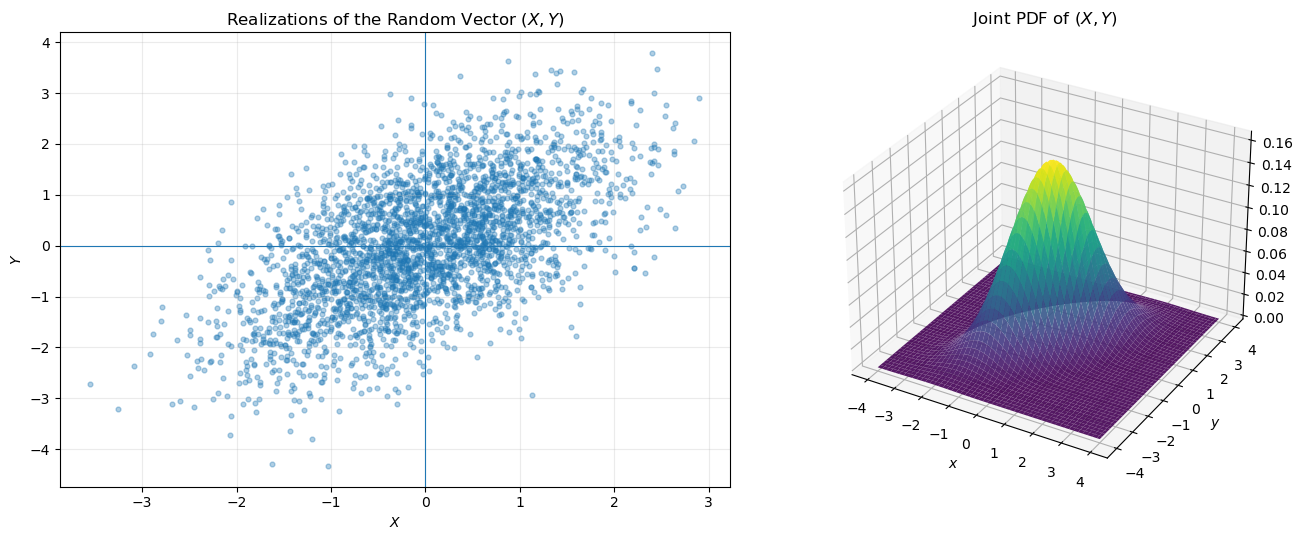

In [5]:
# Random vectors and their joint PDF

# Parameters
mean = np.array([0, 0])

covariance = np.array([
    [1.0, 0.75],
    [0.75, 1.5]
])

# Simulate realizations of the random vector
n = 3000

samples = rng.multivariate_normal(
    mean,
    covariance,
    size=n
)

X = samples[:, 0]
Y = samples[:, 1]

# Construct the joint PDF
distribution = stats.multivariate_normal(
    mean=mean,
    cov=covariance
)

x = np.linspace(-4, 4, 150)
y = np.linspace(-4, 4, 150)

X_grid, Y_grid = np.meshgrid(x, y)
positions = np.dstack((X_grid, Y_grid))

joint_pdf = distribution.pdf(positions)

# Draw both graphs next to each other
fig = plt.figure(figsize=(14, 5.5))

# Realizations of the random vector
ax_1 = fig.add_subplot(1, 2, 1)

ax_1.scatter(
    X,
    Y,
    s=12,
    alpha=0.35
)

ax_1.axhline(0, linewidth=0.8)
ax_1.axvline(0, linewidth=0.8)

ax_1.set_xlabel("$X$")
ax_1.set_ylabel("$Y$")
ax_1.set_title("Realizations of the Random Vector $(X,Y)$")
ax_1.grid(alpha=0.25)

# Three-dimensional joint PDF
ax_2 = fig.add_subplot(
    1,
    2,
    2,
    projection="3d"
)

ax_2.plot_surface(
    X_grid,
    Y_grid,
    joint_pdf,
    cmap="viridis",
    edgecolor="none",
    alpha=0.9
)

ax_2.set_xlabel("$x$")
ax_2.set_ylabel("$y$")
#ax_2.set_zlabel("$f_{X,Y}(x,y)$")
ax_2.set_title("Joint PDF of $(X,Y)$")

plt.tight_layout()
plt.show()

### Properties of the Joint PDF

1. For every Borel set $B\subseteq\mathbb R^n$

$$
\mathbb P(\mathbf X\in B)
=
\int_B
p(x_1,\ldots,x_n)\,dx.
$$

2. If $F$ is differentiable,

$$
p(x_1,\ldots,x_n)
=
\frac{\partial^nF}
{\partial x_1\cdots\partial x_n}.
$$

3.

$$
\int_{\mathbb R^n}
p(x_1,\ldots,x_n)\,dx
=
1.
$$

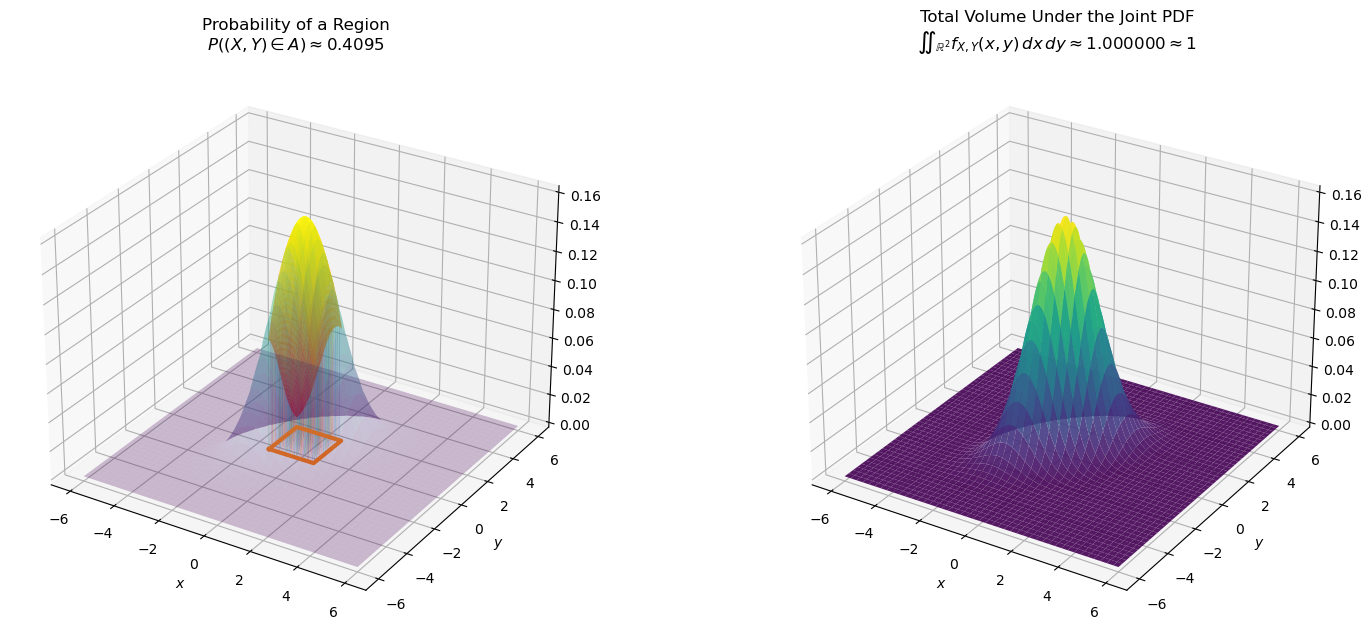

Probability over the selected region: 0.409509
Total volume under the joint PDF: 1.000000


In [12]:
# Probability over a region and total volume under a joint PDF

from scipy.integrate import trapezoid

# ---------------------------------------------------------
# Joint distribution
# ---------------------------------------------------------

mean = np.array([0, 0])

covariance = np.array([
    [1.0, 0.65],
    [0.65, 1.4]
])

distribution = stats.multivariate_normal(
    mean=mean,
    cov=covariance
)

# Wide grid capturing essentially all probability mass
x = np.linspace(-6, 6, 220)
y = np.linspace(-6, 6, 220)

X_grid, Y_grid = np.meshgrid(x, y)
positions = np.dstack((X_grid, Y_grid))

joint_pdf = distribution.pdf(positions)

# Numerical approximation of the total volume
integral_over_y = trapezoid(
    joint_pdf,
    y,
    axis=0
)

total_probability = trapezoid(
    integral_over_y,
    x
)

# ---------------------------------------------------------
# Event A = [a,b] × [c,d]
# ---------------------------------------------------------

a, b = -1.2, 0.8
c, d = -0.6, 1.4

x_region = np.linspace(a, b, 100)
y_region = np.linspace(c, d, 100)

X_region, Y_region = np.meshgrid(
    x_region,
    y_region
)

region_positions = np.dstack(
    (X_region, Y_region)
)

region_pdf = distribution.pdf(region_positions)

# Probability of the selected event
integral_region_y = trapezoid(
    region_pdf,
    y_region,
    axis=0
)

region_probability = trapezoid(
    integral_region_y,
    x_region
)

# ---------------------------------------------------------
# Draw the two graphs next to each other
# ---------------------------------------------------------

fig = plt.figure(figsize=(16, 6.5))

# =========================================================
# Left: probability of a selected region
# =========================================================

ax_1 = fig.add_subplot(
    1,
    2,
    1,
    projection="3d"
)

# Full density as a transparent reference surface
ax_1.plot_surface(
    X_grid,
    Y_grid,
    joint_pdf,
    cmap="viridis",
    edgecolor="none",
    alpha=0.25
)

# Highlighted surface above the selected region
ax_1.plot_surface(
    X_region,
    Y_region,
    region_pdf,
    cmap="autumn",
    edgecolor="none",
    alpha=0.95
)

# Vertical segments emphasizing the volume
step = 8

for i in range(0, len(y_region), step):
    for j in range(0, len(x_region), step):
        ax_1.plot(
            [X_region[i, j], X_region[i, j]],
            [Y_region[i, j], Y_region[i, j]],
            [0, region_pdf[i, j]],
            linewidth=0.6,
            alpha=0.3
        )

# Boundary of A on the xy-plane
rectangle_x = [a, b, b, a, a]
rectangle_y = [c, c, d, d, c]
rectangle_z = [0, 0, 0, 0, 0]

ax_1.plot(
    rectangle_x,
    rectangle_y,
    rectangle_z,
    linewidth=3
)

ax_1.set_xlabel("$x$")
ax_1.set_ylabel("$y$")
#ax_1.set_zlabel("$f_{X,Y}(x,y)$")

ax_1.set_title(
    "Probability of a Region\n"
    rf"$P((X,Y)\in A)\approx {region_probability:.4f}$"
)

ax_1.set_zlim(bottom=0)
ax_1.view_init(elev=28, azim=-58)

# =========================================================
# Right: total volume under the density
# =========================================================

ax_2 = fig.add_subplot(
    1,
    2,
    2,
    projection="3d"
)

# Entire surface represents all possible values of (X,Y)
ax_2.plot_surface(
    X_grid,
    Y_grid,
    joint_pdf,
    cmap="viridis",
    edgecolor="none",
    alpha=0.9
)

# Vertical segments across the full relevant region
step_full = 14

for i in range(0, len(y), step_full):
    for j in range(0, len(x), step_full):
        if joint_pdf[i, j] > 0.001:
            ax_2.plot(
                [X_grid[i, j], X_grid[i, j]],
                [Y_grid[i, j], Y_grid[i, j]],
                [0, joint_pdf[i, j]],
                linewidth=0.45,
                alpha=0.18
            )

ax_2.set_xlabel("$x$")
ax_2.set_ylabel("$y$")
#ax_2.set_zlabel("$f_{X,Y}(x,y)$")

ax_2.set_title(
    "Total Volume Under the Joint PDF\n"
    rf"$\iint_{{\mathbb{{R}}^2}} f_{{X,Y}}(x,y)\,dx\,dy"
    rf"\approx {total_probability:.6f}\approx 1$"
)

ax_2.set_zlim(bottom=0)
ax_2.view_init(elev=28, azim=-58)

plt.tight_layout()
plt.show()

print(
    f"Probability over the selected region: "
    f"{region_probability:.6f}"
)

print(
    f"Total volume under the joint PDF: "
    f"{total_probability:.6f}"
)

## Marginal Distributions

The **marginal PDF** of $X_i$ is obtained by integrating the joint density over all remaining variables.

For example,

$$
p_{X_1}(x_1)
=
\int_{\mathbb R}
\cdots
\int_{\mathbb R}
p(x_1,\ldots,x_n)
\,dx_2\cdots dx_n.
$$

For two random variables $(X,Y)$, the marginal densities are

$$
p_X(x)
=
\int_{-\infty}^{\infty}
p(x,y)\,dy,
$$

and

$$
p_Y(y)
=
\int_{-\infty}^{\infty}
p(x,y)\,dx.
$$

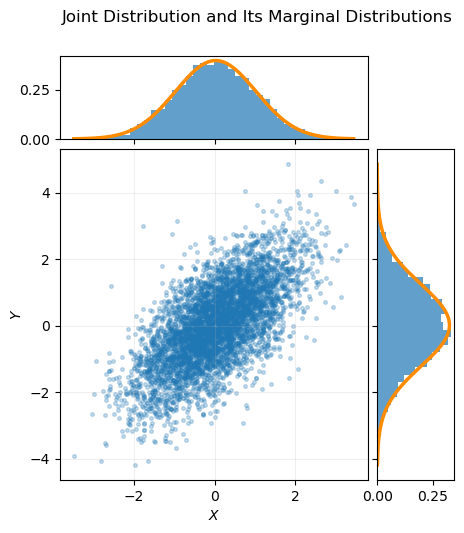

In [14]:
# Generate a dependent random vector
mean = np.array([0, 0])

covariance = np.array([
    [1.0, 0.8],
    [0.8, 1.5]
])

samples = rng.multivariate_normal(
    mean,
    covariance,
    size=5000
)

X = samples[:, 0]
Y = samples[:, 1]

# Parameters of the fitted marginal normal distributions
mu_X = np.mean(X)
sigma_X = np.std(X, ddof=1)

mu_Y = np.mean(Y)
sigma_Y = np.std(Y, ddof=1)

# Create a smaller figure
fig = plt.figure(figsize=(5.8, 5.8))

grid = fig.add_gridspec(
    2,
    2,
    width_ratios=(4, 1),
    height_ratios=(1, 4),
    hspace=0.05,
    wspace=0.05
)

ax_scatter = fig.add_subplot(grid[1, 0])
ax_hist_x = fig.add_subplot(
    grid[0, 0],
    sharex=ax_scatter
)
ax_hist_y = fig.add_subplot(
    grid[1, 1],
    sharey=ax_scatter
)

# ---------------------------------------------------------
# Joint observations
# ---------------------------------------------------------

ax_scatter.scatter(
    X,
    Y,
    s=7,
    alpha=0.25
)

ax_scatter.set_xlabel("$X$")
ax_scatter.set_ylabel("$Y$")
ax_scatter.grid(alpha=0.2)

# ---------------------------------------------------------
# Marginal distribution of X
# ---------------------------------------------------------

ax_hist_x.hist(
    X,
    bins=40,
    density=True,
    alpha=0.7
)

x_grid = np.linspace(
    X.min(),
    X.max(),
    400
)

ax_hist_x.plot(
    x_grid,
    stats.norm.pdf(
        x_grid,
        loc=mu_X,
        scale=sigma_X
    ),
    color="darkorange",
    linewidth=2.5
)

# ---------------------------------------------------------
# Marginal distribution of Y
# ---------------------------------------------------------

ax_hist_y.hist(
    Y,
    bins=40,
    density=True,
    orientation="horizontal",
    alpha=0.7
)

y_grid = np.linspace(
    Y.min(),
    Y.max(),
    400
)

ax_hist_y.plot(
    stats.norm.pdf(
        y_grid,
        loc=mu_Y,
        scale=sigma_Y
    ),
    y_grid,
    color="darkorange",
    linewidth=2.5
)

# Hide duplicated marginal-axis labels
ax_hist_x.tick_params(labelbottom=False)
ax_hist_y.tick_params(labelleft=False)

fig.suptitle(
    "Joint Distribution and Its Marginal Distributions",
    fontsize=12,
    y=0.94
)

# Center the complete plot inside the figure
fig.subplots_adjust(
    left=0.16,
    right=0.84,
    bottom=0.13,
    top=0.86
)

plt.show()

# Independence

Random vectors $\mathbf X_1,\ldots,\mathbf X_n$ are **mutually independent** if

$$
\mathbb P(\mathbf X_1\in B_1,\ldots,\mathbf X_n\in B_n)
=
\prod_{i=1}^n
\mathbb P(\mathbf X_i\in B_i)
$$

for every collection of Borel sets $B_1,\ldots,B_n$.

## Theorem [Criterion for Independence]

Random variables $X_1,\ldots,X_n$ are independent if and only if

$$
\boxed{
F_{X_1,\ldots,X_n}(x_1,\ldots,x_n)
=
\prod_{i=1}^n
F_{X_i}(x_i).
}
$$

### Proposition

Suppose that $X_1,\ldots,X_n$ are independent continuous random variables with PDFs

$$
p_1,\ldots,p_n.
$$

Then $(X_1,\ldots,X_n)$ is an absolutely continuous random vector with joint density

$$
p(x_1,\ldots,x_n)
=
\prod_{i=1}^n
p_i(x_i).
$$

# Convolution Formula

If $X$ and $Y$ are independent continuous random variables, then

$$
\boxed{
p_{X+Y}(x)
=
\int_{-\infty}^{\infty}
p_X(t)
p_Y(x-t)
\,dt.
}
$$

This formula is called the **convolution formula**.

## Example 1: Sum of Independent Normal Random Variables

Let

$$
X\sim N(\mu_1,\sigma_1^2),
\qquad
Y\sim N(\mu_2,\sigma_2^2),
$$

and suppose that $X\perp Y$.

By the convolution formula,

$$
X+Y
\sim
N\!\left(
\mu_1+\mu_2,
\,
\sigma_1^2+\sigma_2^2
\right).
$$

## Example 2: Sum of Independent Gamma Random Variables

Let

$$
X\sim \Gamma(\alpha_1,\lambda),
\qquad
Y\sim \Gamma(\alpha_2,\lambda),
$$

where $\lambda$ is the common rate parameter, and suppose that $X\perp Y$.

By the convolution formula,

$$
X+Y
\sim
\Gamma(\alpha_1+\alpha_2,\lambda).
$$

# Distributions derived from the Normal distribution

## Chi-Squared Distribution

Let $Z_1,\ldots,Z_n$ be independent standard normal random variables, that is,

$$
Z_i\sim N(0,1).
$$

The random variable

$$
\boxed{
X=\sum_{i=1}^{n}Z_i^2
}
$$

is said to have a **Chi-squared distribution** with $n$ degrees of freedom.

We write

$$
X\sim\chi_n^2.
$$

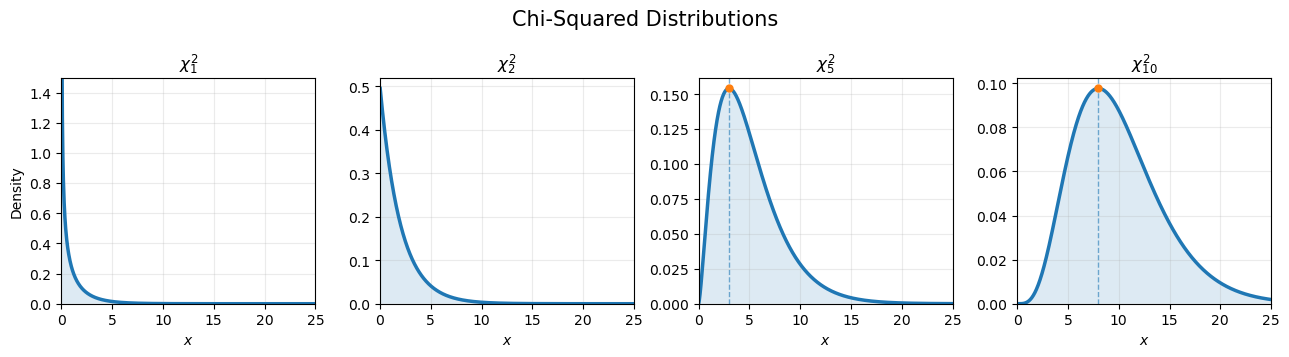

In [20]:
# Chi-squared distributions

degrees_of_freedom = [1, 2, 5, 10]

fig, axes = plt.subplots(
    1,
    4,
    figsize=(13, 3.6),
    sharex=True
)

x = np.linspace(0.02, 25, 1000)

for ax, df in zip(axes, degrees_of_freedom):

    density = stats.chi2.pdf(x, df=df)

    ax.plot(
        x,
        density,
        linewidth=2.5
    )

    ax.fill_between(
        x,
        density,
        alpha=0.15
    )

    # Mark the mode when it exists
    if df > 2:
        mode = df - 2
        mode_density = stats.chi2.pdf(mode, df=df)

        ax.scatter(
            mode,
            mode_density,
            s=25,
            zorder=3
        )

        ax.axvline(
            mode,
            linestyle="--",
            linewidth=1,
            alpha=0.6
        )

    ax.set_title(
        rf"$\chi^2_{{{df}}}$",
        fontsize=12
    )

    ax.set_xlim(0, 25)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.25)

# Limit only the first panel
axes[0].set_ylim(0, 1.5)

# Labels only where needed
axes[0].set_ylabel("Density")

for ax in axes:
    ax.set_xlabel("$x$")

fig.suptitle(
    "Chi-Squared Distributions",
    fontsize=15
)

fig.tight_layout()
plt.show()

## Student's $t$ Distribution

Let $Z\sim N(0,1)$, and $X\sim\chi_n^2$, where $Z$ and $X$ are independent.

The random variable

$$
\boxed{
T=
\frac{Z}{\sqrt{X/n}}
}
$$

is said to have a **Student's $t$ distribution** with $n$ degrees of freedom.

We write

$$
T\sim t_n.
$$

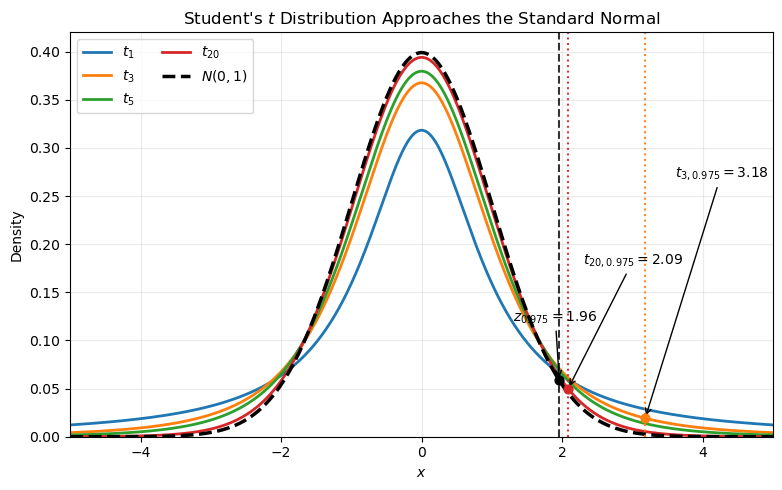

In [24]:
x = np.linspace(-5, 5, 1000)
degrees_of_freedom = [1, 3, 5, 20]

fig, ax = plt.subplots(figsize=(8, 5))

# Plot t distributions
for df in degrees_of_freedom:
    ax.plot(
        x,
        stats.t.pdf(x, df=df),
        linewidth=2,
        label=rf"$t_{{{df}}}$"
    )

# Plot standard normal
normal_pdf = stats.norm.pdf(x)

ax.plot(
    x,
    normal_pdf,
    linestyle="--",
    color="black",
    linewidth=2.5,
    label=r"$N(0,1)$"
)

# ---------------------------------------------------------
# 97.5% quantiles
# ---------------------------------------------------------

z975 = stats.norm.ppf(0.975)
t3 = stats.t.ppf(0.975, df=3)
t20 = stats.t.ppf(0.975, df=20)

# Vertical lines
ax.axvline(z975, color="black", linestyle="--", alpha=0.8)
ax.axvline(t20, color="C3", linestyle=":", alpha=0.9)
ax.axvline(t3, color="C1", linestyle=":", alpha=0.9)

# Points on the curves
ax.scatter(
    z975,
    stats.norm.pdf(z975),
    color="black",
    s=40,
    zorder=5
)

ax.scatter(
    t20,
    stats.t.pdf(t20, df=20),
    color="C3",
    s=40,
    zorder=5
)

ax.scatter(
    t3,
    stats.t.pdf(t3, df=3),
    color="C1",
    s=40,
    zorder=5
)

# Labels
ax.annotate(
    rf"$z_{{0.975}}={z975:.2f}$",
    xy=(z975, stats.norm.pdf(z975)),
    xytext=(1.3, 0.12),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

ax.annotate(
    rf"$t_{{20,0.975}}={t20:.2f}$",
    xy=(t20, stats.t.pdf(t20, df=20)),
    xytext=(2.3, 0.18),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

ax.annotate(
    rf"$t_{{3,0.975}}={t3:.2f}$",
    xy=(t3, stats.t.pdf(t3, df=3)),
    xytext=(3.6, 0.27),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

# ---------------------------------------------------------

ax.set_xlabel("$x$")
ax.set_ylabel("Density")

ax.set_title(
    "Student's $t$ Distribution Approaches the Standard Normal"
)

ax.legend(ncol=2)
ax.grid(alpha=0.25)

ax.set_xlim(-5, 5)
ax.set_ylim(0, 0.42)

plt.tight_layout()
plt.show()

## Fisher's $F$ Distribution

Let

$$
X\sim\chi_n^2,
\qquad
Y\sim\chi_m^2,
$$

where $X$ and $Y$ are independent.

The random variable

$$
\boxed{
F=
\frac{X/n}{Y/m}
}
$$

is said to have a **Fisher's $F$ distribution** with $(n,m)$ degrees of freedom.

We write

$$
F\sim F_{n,m}.
$$

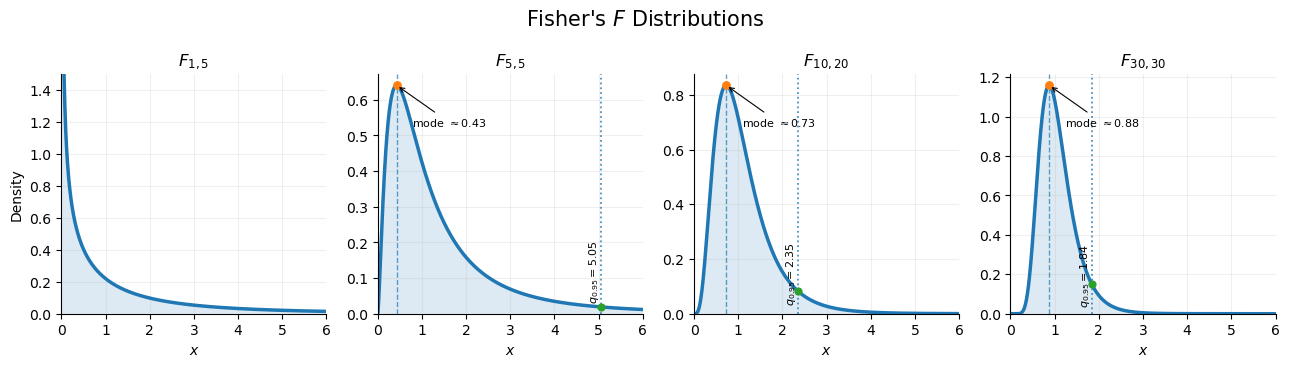

In [25]:
# Fisher's F distributions

parameter_pairs = [
    (1, 5),
    (5, 5),
    (10, 20),
    (30, 30)
]

fig, axes = plt.subplots(
    1,
    4,
    figsize=(13, 3.7),
    sharex=True
)

x = np.linspace(0.001, 6, 1500)

for ax, (df_1, df_2) in zip(axes, parameter_pairs):

    density = stats.f.pdf(
        x,
        dfn=df_1,
        dfd=df_2
    )

    ax.plot(
        x,
        density,
        linewidth=2.5
    )

    ax.fill_between(
        x,
        density,
        alpha=0.15
    )

    # Mode exists away from zero when df_1 > 2
    if df_1 > 2:
        mode = (
            (df_1 - 2) / df_1
        ) * (
            df_2 / (df_2 + 2)
        )

        mode_density = stats.f.pdf(
            mode,
            dfn=df_1,
            dfd=df_2
        )

        ax.axvline(
            mode,
            linestyle="--",
            linewidth=1,
            alpha=0.7
        )

        ax.scatter(
            mode,
            mode_density,
            s=28,
            zorder=3
        )

        ax.annotate(
            rf"mode $\approx {mode:.2f}$",
            xy=(mode, mode_density),
            xytext=(mode + 0.35, 0.82 * mode_density),
            arrowprops={
                "arrowstyle": "->",
                "linewidth": 0.8
            },
            fontsize=8
        )

    # 95th percentile
    q95 = stats.f.ppf(
        0.95,
        dfn=df_1,
        dfd=df_2
    )

    if q95 <= 6:
        q95_density = stats.f.pdf(
            q95,
            dfn=df_1,
            dfd=df_2
        )

        ax.axvline(
            q95,
            linestyle=":",
            linewidth=1.3,
            alpha=0.8
        )

        ax.scatter(
            q95,
            q95_density,
            s=24,
            zorder=3
        )

        ax.text(
            q95,
            0.03,
            rf"$q_{{0.95}}={q95:.2f}$",
            rotation=90,
            va="bottom",
            ha="right",
            fontsize=8
        )

    ax.set_title(
        rf"$F_{{{df_1},{df_2}}}$",
        fontsize=12
    )

    ax.set_xlim(0, 6)
    ax.set_ylim(bottom=0)
    ax.set_xlabel("$x$")
    ax.grid(alpha=0.2)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# The first density diverges near zero, so cap its vertical scale
axes[0].set_ylim(0, 1.5)

axes[0].set_ylabel("Density")

fig.suptitle(
    "Fisher's $F$ Distributions",
    fontsize=15
)

fig.tight_layout()
plt.show()